## **Ćwiczenia 10: miRNAs, struktura RNA, gramatyka**
*Aleksander Stanuch*

### **Zadanie 1 (3pkt):**
Dla podanej sekwencji pre-miRNA:
<div style="font-family: 'Courier New', Courier, monospace;">
>pre-mirna <br>
CUUUUAAAUUCUGUUGCAGCAGAUAGCUGAUACCCAAUGUUAUCUUUUGCGGCAGAAAUUGAAAG
</div>

1. **Podaj identyfikatory miRNAs pochodzących z tej sekwencji, jaki to gatunek? Wykorzystaj bazę miRBase:**

    - MIMAT0000996
    - MIMAT0000997

2. **Jakie jednostki chorobowe u człowieka są powiązane z nimi?**

    - Mononukleoza zakaźna
    - Chłoniak
    - Skleroza

3. **Podaj identyfikatory potencjalnych regulowanych genów (człowiek) (miRTarBase)**

    - EBNA1BP2
    - TP53

#### **Zadanie 2 (2pkt)**
Dla podanej macierzy kropkowej podaj odpowiadającą strukturę w formacie Vienna:

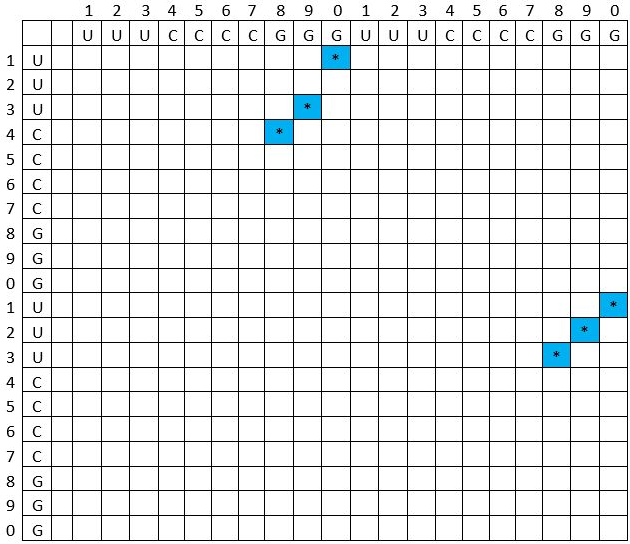

Struktura w formacie Vienna: (.((...)))(((....)))

### **Zadanie 3. (4pkt)**

Używając podanej sekwencji RNA (72 nt): 
`GGGCCCAUAGCUCAGUGGUAGAGUGCCUCCUUUGCAAGGAGGAUGCCCUGGGUUCGAAUCCCAGUGGGUCCA`


**1. Identyfikacja cząsteczki:**

-  **Baza RFAM:** Haloarchaeobius sp. HME9146 tRNA-Ala
-  **Struktura referencyjna (Vienna):** `(((((((..((((.......)))).(((((.......))))).....(((((.......)))))))))))).`
-  **Reprezentacja planarna:** Jest to struktura liścia koniczyny, składająca się z pnia oraz trzech pętli.

**2. i 3. Tabela wyników predykcji:**

| | Nussinov | RNAfold | CentroidFold | Referencja (RFAM) |
| :-: | :-: | :-: | :-: | :-: |
| **Struktura** | `(((.)).)(((((((((.))((.)((((.((((..))))))(.)))))))))))(((.))(((.))))(..)` | `((((((((((((((.((((.....(((((((...))))))).))))))))))).........)))))))).` | `(((((((..((((.......)))).(((((((...))))))).....(((((.......)))))))))))).` | `(((((((..((((.......)))).(((((.......))))).....(((((.......)))))))))))).` |
| **l. wiązań =** | 30 | 25 | 23 | 21 |
| **en. swobodna [kcal/mol]=** | +799,984.75* | -33.60 | -31.50 | - |

*\*Wartość dla Nussinov jest strasznie wysoka, ponieważ program RNAeval nałożył maksymalne kary za niemożliwe pętle.*

**4. Wskazanie poprawnej predykcji i uzasadnienie**

Najbardziej poprawną biologicznie predykcję dał algorytm CentroidFold. Jego struktura jest niemal identyczna z referencją z bazy RFAM. 

- **Nussinov:** Ten algorytm maksymalizuje liczbę wiązań wodorowych do 30, ale stworzył niefizyczne połączenia cząsteczki. Wysoka energia swobodna sugeruje, że taka cząsteczka w naturze nie może istnieć.

- **RNAfold:** Znalazł strukturę o najniższej energii matematycznej (-33.60 kcal/mol), jednak utraciła ona kształt liścia koniczyny.

![Struktura dla RNAfold.png](<attachment:Struktura dla RNAfold.png>)

- **CentroidFold:** Wypadł najlepiej. Poprawnie przewidział liście koniczyny, osiągając wynik najbliższy referencji.

![Struktura dla CentroidFold.png](<attachment:Struktura dla CentroidFold.png>)

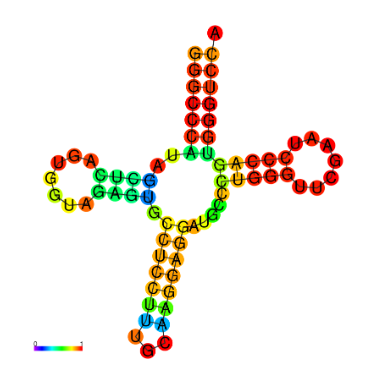
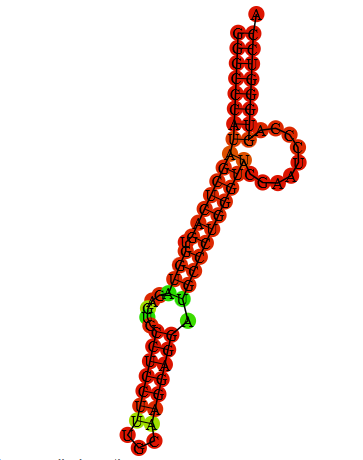

### **Zadanie 4 (4pkt):**

**1. Zdefiniowane reguły produkcji:**

Aby zamodelować motyw [LIFAT]-{IL}-x(2)-W-x(2,3)-[PE], symbol startowy $S$ musi uwzględniać dwie możliwe długości łańcucha (8 lub 9 znaków).

Symbole nieterminalne odpowiadają dozwolonym aminokwasom:
- P1 -> L | I | F | A | T
- P2 -> dowolny z 20 aminokwasów OPRÓCZ 'I' oraz 'L'
- PE -> P | E
- X -> dowolny z 20 standardowych aminokwasów

**2. Weryfikacja sekwencji (Parsowanie):**

Powyższa gramatyka została zweryfikowana algorytmicznie (skrypt Python / biblioteka NLTK). Wyniki dla podanych sekwencji:

1. iadkwpalp (długość 9): Spełnia reguły
2. iadkwplp (długość 8): Spełnia reguły
3. amfewpe (długość 7): Nie spełnia reguł (sekwencja jest zbyt krótka, minimalna długość to 8)
4. tqrewgrlp (długość 9): Spełnia reguły

In [1]:
import nltk
from nltk.grammar import CFG

grammar_str = """
S -> P1 P2 X X 'w' X X PE | P1 P2 X X 'w' X X X PE
P1 -> 'l' | 'i' | 'f' | 'a' | 't'
P2 -> 'a'|'r'|'n'|'d'|'c'|'q'|'e'|'g'|'h'|'k'|'m'|'f'|'p'|'s'|'t'|'w'|'y'|'v'
PE -> 'p' | 'e'
X -> 'a'|'r'|'n'|'d'|'c'|'q'|'e'|'g'|'h'|'i'|'l'|'k'|'m'|'f'|'p'|'s'|'t'|'w'|'y'|'v'
"""

grammar = CFG.fromstring(grammar_str)
parser = nltk.ChartParser(grammar)

sequences = [
    list("iadkwpalp"),
    list("iadkwplp"),
    list("amfewpe"),
    list("tqrewgrlp")
]

for i, seq in enumerate(sequences, 1):
    seq_str = "".join(seq)
    trees = list(parser.parse(seq))
    
    if len(trees) > 0:
        print(f"{i}. {seq_str}: Pasuje do reguł")
    else:
        print(f"{i}. {seq_str}: Nie pasuje do reguł")

1. iadkwpalp: Pasuje do reguł
2. iadkwplp: Pasuje do reguł
3. amfewpe: Nie pasuje do reguł
4. tqrewgrlp: Pasuje do reguł


### **Zadanie 5 (7pkt):**

Rozważmy dopasowanie MSA 5. sekwencji. Dla tego dopasowania ustalono wspólną strukturę II rzędową podaną w formacie Vienna.
<div style="font-family: 'Courier New', Courier, monospace;">
&nbsp&nbsp&nbsp&nbsp&nbsp&nbsp123456789012345678901234<br>
human&nbspAAGACUUCGGAUCUGGCGACACCC<br>
mouse&nbspUACACUUCGGAUGACACCAAAGUG<br>
worm&nbsp&nbspAGGUCUUCGGCACGGGCACCAUUA<br>
fly&nbsp&nbsp&nbspCCAACUUCGGAUUUUGCUACCAUA<br>
orc&nbsp&nbsp&nbspAAGCCUUCGGAGCGGGCGUAACUC<br>
struc ..(((....).)).((.(...)))  
</div>

**1. Budowa Gramatyki:**

Z uwagi na to, że zadana struktura `..(((....).)).((.(...)))` posiada rozwidlenie (dwie pętle), zdefiniowano symbol startowy jako **S -> LR**. Lewa część (L) odpowiada za indeksy 0-12, a prawa (R) indeksy 13-23.

**2. Przeprowadzenie estymacji parametrów modelu:**

Gramatyki dla wszystkich sekwencji zostały sprowadzone do Postaci Normalnej Chomskiego (CNF). Następnie, wykorzystano metodę `nltk.induce_pcfg` i wyestymowano prawdopodobieństwa poszczególnych reguł

**3. Dopasowanie każdej z sekwencji MSA do modelu:**

Dopasowanie zrealizowano za pomocą algorytmu Viterbi CKY (`ViterbiParser`).

**4. Wyniki Prawdopodobieństw Generacji:**
1. human - prawdopodobieństwo: 0.03185%
2. orc - prawdopodobieństwo: 0.01062%
3. mouse - prawdopodobieństwo: 0.00044%
4. fly - prawdopodobieństwo: 0.00044%
5. worm - prawdopodobieństwo: 0.00022%

In [ ]:
import nltk
from nltk import PCFG, Nonterminal
from nltk.parse import ViterbiParser

sequences = {
    'human': 'AAGACUUCGGAUCUGGCGACACCC',
    'mouse': 'UACACUUCGGAUGACACCAAAGUG',
    'worm':  'AGGUCUUCGGCACGGGCACCAUUA',
    'fly':   'CCAACUUCGGAUUUUGCUACCAUA',
    'orc':   'AAGCCUUCGGAGCGGGCGUAACUC'
}

def generate_grammar(seq):
    return PCFG.fromstring(f"""
S -> L R [1.0]
L -> {seq[0]} L1 [1.0]
L1 -> {seq[1]} L2 [1.0]
L2 -> {seq[2]} L3 {seq[12]} [1.0]
L3 -> {seq[3]} L4 {seq[11]} [1.0]
L4 -> L5 {seq[10]} [1.0]
L5 -> {seq[4]} L6 {seq[9]} [1.0]
L6 -> {seq[5]} L7 [1.0]
L7 -> {seq[6]} L8 [1.0]
L8 -> {seq[7]} {seq[8]} [1.0]

R -> {seq[13]} R1 [1.0]
R1 -> {seq[14]} R2 {seq[23]} [1.0]
R2 -> {seq[15]} R3 {seq[22]} [1.0]
R3 -> {seq[16]} R4 [1.0]
R4 -> {seq[17]} R5 {seq[21]} [1.0]
R5 -> {seq[18]} R6 [1.0]
R6 -> {seq[19]} {seq[20]} [1.0]

A -> 'a' [1.0]
C -> 'c' [1.0]
G -> 'g' [1.0]
U -> 'u' [1.0]
""")

grammars = {name: generate_grammar(seq) for name, seq in sequences.items()}

S_sym = Nonterminal('S')
productions = []

for name, g in grammars.items():
    g.chomsky_normal_form()
    productions += g.productions()

all_grammar = nltk.induce_pcfg(S_sym, productions)

parser = ViterbiParser(all_grammar)

results = {}
for name, seq in sequences.items():
    best_parse = list(parser.parse(list(seq.lower())))[0] 
    prob = best_parse.prob()
    results[name] = prob
    print(f"{name} - prawdopodobieństwo: {prob:.5%}")

best_seq = max(results, key=results.get)
print(f"\nnajwiększe prawdopodobieństwo: {best_seq} ({results[best_seq]:.5%})")

human - prawdopodobieństwo: 0.03185%
mouse - prawdopodobieństwo: 0.00044%
worm - prawdopodobieństwo: 0.00022%
fly - prawdopodobieństwo: 0.00044%
orc - prawdopodobieństwo: 0.01062%

największe prawdopodobieństwo: human (0.03185%)
